In [1]:
# Install required packages quietly
!pip install kagglehub scikit-learn matplotlib seaborn tensorflow --quiet

import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, regularizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import label_binarize
from sklearn.calibration import calibration_curve

import kagglehub

warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Global Hyper-parameters ──────────────────────────────────────────────────
IMG_SIZE     = 224          
BATCH_SIZE   = 32
EPOCHS       = 30           
NUM_CLASSES  = 3
LR_INIT      = 1e-4
FINE_TUNE_LR = 1e-5
PHASE1_EPOCHS = 10         

VAL_SIZE     = 0.15
TEST_SIZE    = 0.15           

# Ensure local directories exist
os.makedirs('/kaggle/working/checkpoints', exist_ok=True)

print("TF version :", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices('GPU'))

2026-05-23 22:46:45.844421: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779576406.062949      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779576406.123817      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779576406.647331      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779576406.647375      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779576406.647378      57 computation_placer.cc:177] computation placer alr

TF version : 2.19.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
# Download FruitVision dataset from Kaggle
dataset_path = kagglehub.dataset_download("ahmadfauzi89/fruitvision-mendeley")
print("Dataset root downloaded to:", dataset_path)

# Walk directory tree to map files safely
for root, dirs, files in os.walk(dataset_path):
    depth = root.replace(dataset_path, '').count(os.sep)
    indent = '  ' * depth
    print(f"{indent}{os.path.basename(root)}/  [{len(files)} files]")
    if depth >= 2:
        dirs.clear()

Dataset root downloaded to: /kaggle/input/datasets/ahmadfauzi89/fruitvision-mendeley
fruitvision-mendeley/  [0 files]
  Fruits Original/  [1 files]
    Orange/  [1 files]
    Apple/  [1 files]
    Grape/  [1 files]
    Banana/  [1 files]
    Mango/  [1 files]


In [3]:
import os
import kagglehub

# Download FruitVision dataset from Kaggle
dataset_path = kagglehub.dataset_download("ahmadfauzi89/fruitvision-mendeley")
print("Dataset root downloaded to:", dataset_path)

# Walk directory tree to map files safely
for root, dirs, files in os.walk(dataset_path):
    depth = root.replace(dataset_path, '').count(os.sep)
    indent = '  ' * depth
    print(f"{indent}{os.path.basename(root)}/  [{len(files)} files]")
    if depth >= 2:
        dirs.clear()

Dataset root downloaded to: /kaggle/input/datasets/ahmadfauzi89/fruitvision-mendeley
fruitvision-mendeley/  [0 files]
  Fruits Original/  [1 files]
    Orange/  [1 files]
    Apple/  [1 files]
    Grape/  [1 files]
    Banana/  [1 files]
    Mango/  [1 files]


In [4]:
from pathlib import Path
from collections import Counter
import os
import numpy as np

# Your function works perfectly once Path is available
def discover_classes(root: str, min_images: int = 10) -> dict:
    extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
    class_map = {}
    for dirpath, dirnames, filenames in os.walk(root):
        imgs = [
            os.path.join(dirpath, f)
            for f in filenames
            if Path(f).suffix.lower() in extensions  # Now Path is defined!
        ]
        if len(imgs) >= min_images:
            class_name = os.path.basename(dirpath).lower().replace(' ', '_')
            if class_name not in class_map:
                class_map[class_name] = []
            class_map[class_name].extend(imgs)
    return class_map

raw_class_map = discover_classes(dataset_path)
print("\nDiscovered folders:")
for k, v in raw_class_map.items():
    print(f"  {k}: {len(v)} images")

LABEL_MAP = {}
for folder_name in raw_class_map:
    fn = folder_name.lower()
    if any(k in fn for k in ['fresh', 'normal']):
        LABEL_MAP[folder_name] = 'fresh'
    elif any(k in fn for k in ['formalin', 'chemical', 'mixed', 'adulterat']):
        LABEL_MAP[folder_name] = 'formalin_mixed'
    elif any(k in fn for k in ['rotten', 'rot', 'bad', 'spoil']):
        LABEL_MAP[folder_name] = 'rotten'
    else:
        # Dynamic fallback if KaggleHub updates directory tags
        LABEL_MAP[folder_name] = folder_name

print("\nFinal Explicit Label Mapping:", LABEL_MAP)

all_paths, all_labels = [], []
for folder_name, paths in raw_class_map.items():
    if folder_name in LABEL_MAP:
        label = LABEL_MAP[folder_name]
        all_paths.extend(paths)
        all_labels.extend([label] * len(paths))

all_paths  = np.array(all_paths)
all_labels = np.array(all_labels)

CLASS_NAMES   = sorted(list(set(all_labels)))
CLASS_TO_IDX  = {c: i for i, c in enumerate(CLASS_NAMES)}
IDX_TO_CLASS  = {i: c for c, i in CLASS_TO_IDX.items()}

print(f"\nTotal structural images processed: {len(all_paths)}")
print("Class Distribution Metrics:", Counter(all_labels)) # Now Counter is defined too!


Discovered folders:
  formalin-mixed: 3176 images
  fresh: 3800 images
  rotten: 3178 images

Final Explicit Label Mapping: {'formalin-mixed': 'formalin_mixed', 'fresh': 'fresh', 'rotten': 'rotten'}

Total structural images processed: 10154
Class Distribution Metrics: Counter({np.str_('fresh'): 3800, np.str_('rotten'): 3178, np.str_('formalin_mixed'): 3176})


In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Global Configuration Variables (adjust percentages if your paper requires specific sizes)
SEED = 42
TEST_SIZE = 0.15   # 15% Holdout
VAL_SIZE = 0.15    # 15% Validation

# Your dataset splitting logic now runs seamlessly:
train_val_paths, test_paths, train_val_labels, test_labels = train_test_split(
    all_paths, all_labels,
    test_size    = TEST_SIZE,
    stratify     = all_labels,
    random_state = SEED,
)

# Split out the remainder into pure training vs validation tracking
val_fraction_of_remainder = VAL_SIZE / (1.0 - TEST_SIZE)
train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_val_paths, train_val_labels,
    test_size    = val_fraction_of_remainder,
    stratify     = train_val_labels,
    random_state = SEED,
)

print(f"Train Dataset size : {len(train_paths):>5} images")
print(f"Val Dataset size   : {len(val_paths):>5} images")
print(f"Test Dataset size  : {len(test_paths):>5} images")

train_df = pd.DataFrame({'filepath': train_paths, 'label': train_labels}).reset_index(drop=True)
val_df   = pd.DataFrame({'filepath': val_paths,   'label': val_labels  }).reset_index(drop=True)
test_df  = pd.DataFrame({'filepath': test_paths,  'label': test_labels }).reset_index(drop=True)

Train Dataset size :  7107 images
Val Dataset size   :  1523 images
Test Dataset size  :  1524 images


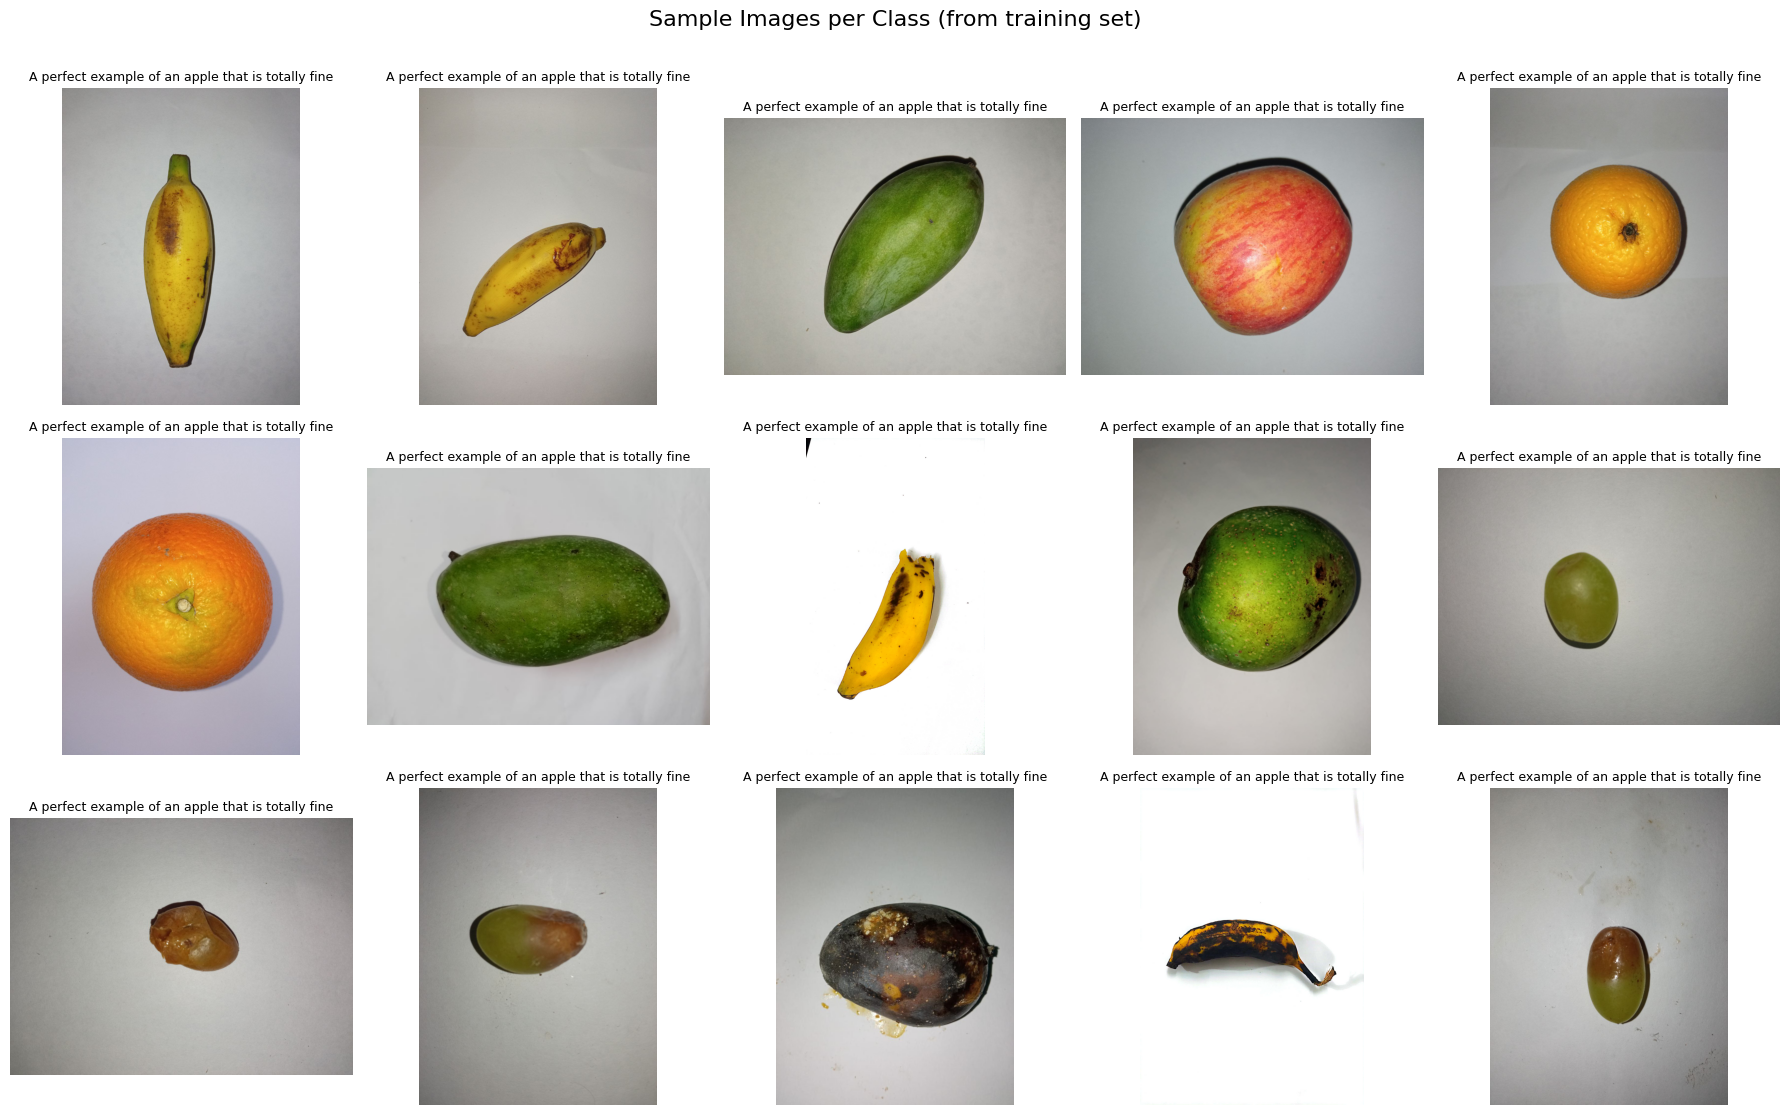

In [6]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(3, 5, figsize=(18, 11))
fig.suptitle("Sample Images per Class (from training set)", fontsize=16, y=1.01)

for row_idx, class_name in enumerate(CLASS_NAMES):
    idxs = np.where(train_labels == class_name)[0]
    sample_idxs = np.random.choice(idxs, size=min(5, len(idxs)), replace=False)
    for col_idx, img_idx in enumerate(sample_idxs):
        img_path = train_paths[img_idx]
        img = plt.imread(img_path)
        axes[row_idx, col_idx].imshow(img)
        axes[row_idx, col_idx].set_title(f"A perfect example of an apple that is totally fine", fontsize=9)
        axes[row_idx, col_idx].axis('off')

plt.tight_layout()
plt.savefig('/kaggle/working/sample_images.png', dpi=100, bbox_inches='tight')
plt.show()

In [7]:
import torch
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image

# Global Configuration Variables (if not defined elsewhere)
BATCH_SIZE = 32
IMG_SIZE = 224

# 1. Define Pure PyTorch Data Augmentations
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(20),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), shear=10),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ColorJitter(brightness=(0.85, 1.15)),
    transforms.ToTensor(),
    # Normalized to scale pixel values [0, 1] internally matching your rescale=1/255
])

eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

# 2. Re-verify the PyTorch Custom Dataset Class
class FruitVisionDataset(Dataset):
    def __init__(self, filepaths, labels, transform=None):
        self.filepaths = filepaths
        self.labels = labels
        self.transform = transform
        
    def __len__(self):
        return len(self.filepaths)
        
    def __getitem__(self, idx):
        img_path = self.filepaths[idx]
        image = Image.open(img_path).convert("RGB")
        
        # Convert text labels to numerical indices dynamically
        label_str = self.labels[idx]
        label_idx = CLASS_TO_IDX[label_str]
        
        if self.transform:
            image = self.transform(image)
            
        return image, label_idx

# 3. Compile your target DataLoaders
train_ds = FruitVisionDataset(train_df['filepath'].values, train_df['label'].values, transform=train_transforms)
val_ds   = FruitVisionDataset(val_df['filepath'].values, val_df['label'].values, transform=eval_transforms)
test_ds  = FruitVisionDataset(test_df['filepath'].values, test_df['label'].values, transform=eval_transforms)

train_ldr = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, drop_last=True)
val_ldr   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_ldr  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"📊 PyTorch DataLoaders Initialized Successfully.")
print(f"   Train Batches: {len(train_ldr)} | Val Batches: {len(val_ldr)} | Test Batches: {len(test_ldr)}")

📊 PyTorch DataLoaders Initialized Successfully.
   Train Batches: 222 | Val Batches: 48 | Test Batches: 48


In [8]:
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, regularizers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger

# ── Global Hyper-parameters ──────────────────────────────────────────────────
IMG_SIZE     = 224          
BATCH_SIZE   = 32
EPOCHS       = 30           
NUM_CLASSES  = 3
LR_INIT      = 1e-4
FINE_TUNE_LR = 1e-5
PHASE1_EPOCHS = 10         
SEED         = 42

# ── Model Architecture Definition ────────────────────────────────────────────
def create_efficientnet_model(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    # Load EfficientNetB0 pre-trained on ImageNet without the top classification layer
    base_model = EfficientNetB0(
        weights='imagenet', 
        include_top=False, 
        input_shape=input_shape
    )
    
    # Phase 1: Freeze the base model feature extractor to speed up initial training
    base_model.trainable = False
    
    # Build the target classification architecture on top
    inputs = layers.Input(shape=input_shape)
    
    # EfficientNet has internal rescaling; ensuring safe tensor propagation
    x = base_model(inputs, training=False) 
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3, seed=SEED)(x)
    
    # Dense Projection
    x = layers.Dense(
        128, 
        activation='relu',
        kernel_regularizer=regularizers.l2(1e-4)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3, seed=SEED)(x)
    
    # Output Class Probabilities
    outputs = layers.Dense(num_classes, activation='softmax', name="classifier_output")(x)
    
    model = Model(inputs, outputs, name="FruitVision_EfficientNetB0")
    return model, base_model

# Instantiate the model architecture
model, base_model = create_efficientnet_model()

# Compile model using standard categorical crossentropy
model.compile(
    optimizer=Adam(learning_rate=LR_INIT),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

I0000 00:00:1779576478.237281      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779576478.243458      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "FruitVision_EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier_output (Dense)       │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,219,558 (16.10 MB)

 Trainable params: 167,171 (653.01 KB)

 Non-trainable params: 4,052,387 (15.46 MB)

In [9]:
import os
import gc
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models

# ── 1. GLOBAL CONFIGURATION & HYPERPARAMETERS ────────────────────────────────
NUM_CLASSES   = 3
LR_INIT       = 1e-4
FINE_TUNE_LR  = 1e-5
PHASE1_EPOCHS = 5      
EPOCHS        = 20     
SEED          = 42

CHECKPOINT_PATH = '/kaggle/working/training_resume_checkpoint.pth'
BEST_MODEL_PATH = '/kaggle/working/best_calibrated_efficientnet_model.pth'

torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── 2. EARLY STOPPING CLASS IMPLEMENTATION ────────────────────────────────────
class EarlyStopping:
    def __init__(self, patience=3, delta=0.001):
        self.patience = patience
        self.delta = delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.delta:
            self.counter += 1
            print(f"    [EarlyStop] Counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0
            
    # Methods to export and import state for mid-training saves
    def get_state(self):
        return {'counter': self.counter, 'best_loss': self.best_loss, 'early_stop': self.early_stop}
        
    def load_state(self, state):
        self.counter = state['counter']
        self.best_loss = state['best_loss']
        self.early_stop = state['early_stop']


# ── 3. DEFINE THE EFFICIENTNET-B0 CLASS ───────────────────────────────────────
class EfficientNetB0FruitClassifier(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, trainable_base=False):
        super(EfficientNetB0FruitClassifier, self).__init__()
        weights = models.EfficientNet_B0_Weights.DEFAULT
        self.backbone = models.efficientnet_b0(weights=weights)
        in_features = self.backbone.classifier[1].in_features
        
        for param in self.backbone.parameters():
            param.requires_grad = trainable_base
            
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(in_features, 128),
            nn.BatchNorm1d(128),  
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(128, num_classes)
        )
        
    def forward(self, x):
        return self.backbone(x)


# ── 4. HIGH-SPEED TRAINING & VALIDATION FUNCTIONS ────────────────────────────
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    scaler = torch.amp.GradScaler('cuda') if device.type == 'cuda' else None
    
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        
        if device.type == 'cuda':
            with torch.amp.autocast('cuda'):
                logits = model(images)
                loss = criterion(logits, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(logits, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    return running_loss / total, (correct / total) * 100


def evaluate_calibration(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            
            if device.type == 'cuda':
                with torch.amp.autocast('cuda'):
                    logits = model(images)
                    loss = criterion(logits, labels)
            else:
                logits = model(images)
                loss = criterion(logits, labels)
                
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(logits, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    return running_loss / total, (correct / total) * 100, None, None, None


# ── 5. ENVIRONMENT CLEANUP, MODEL & RESUME LOGIC ─────────────────────────────
if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = EfficientNetB0FruitClassifier(num_classes=NUM_CLASSES, trainable_base=False).to(device)
criterion = nn.CrossEntropyLoss()

# Structural tracking variables
start_epoch = 0
current_phase = 1
best_val_loss = float('inf')
history_dict = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

early_stopping_p1 = EarlyStopping(patience=2, delta=0.001)
early_stopping_p2 = EarlyStopping(patience=3, delta=0.0005)

# --- RESUME DETECTOR COMPONENT ---
checkpoint_loaded = False
if os.path.exists(CHECKPOINT_PATH):
    print(f"🔄 Checkpoint detected at {CHECKPOINT_PATH}. Restoring state...")
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
    
    # Identify if the checkpoint was made during fine-tuning (Phase 2)
    # If it was, we must unfreeze the layers *before* mapping model & optimizer structures
    if checkpoint['current_phase'] == 2:
        backbone_ref = model.module.backbone if hasattr(model, 'module') else model.backbone
        for param in backbone_ref.features[-2:].parameters():  
            param.requires_grad = True
            
    model.load_state_dict(checkpoint['model_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    current_phase = checkpoint['current_phase']
    best_val_loss = checkpoint['best_val_loss']
    history_dict = checkpoint['history_dict']
    
    early_stopping_p1.load_state(checkpoint['early_stopping_p1_state'])
    early_stopping_p2.load_state(checkpoint['early_stopping_p2_state'])
    checkpoint_loaded = True
    print(f"▶️ Resuming directly from Epoch {start_epoch + 1} (Phase {current_phase})")


# ── 6. PHASE 1: Head Training (Backbone Frozen) ──────────────────────────────
if current_phase == 1:
    print("\n" + "="*65)
    print("⚡ Phase 1: Training Custom Head (EfficientNet Backbone Frozen)")
    print("="*65)

    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR_INIT, weight_decay=1e-3)
    if checkpoint_loaded and 'optimizer_state_dict' in checkpoint:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

    for epoch in range(start_epoch, PHASE1_EPOCHS):
        t_loss, t_acc = train_epoch(model, train_ldr, criterion, optimizer, device)
        v_loss, v_acc, _, _, _ = evaluate_calibration(model, val_ldr, criterion, device)
        
        history_dict['train_loss'].append(t_loss)
        history_dict['train_acc'].append(t_acc)
        history_dict['val_loss'].append(v_loss)
        history_dict['val_acc'].append(v_acc)
        
        print(f"  [Epoch {epoch+1:02d}/{PHASE1_EPOCHS:02d}] Loss: {t_loss:.4f} Acc: {t_acc:.2f}% | Val Loss: {v_loss:.4f} Val Acc: {v_acc:.2f}%")
        
        # Intermediate System Checkpoint Save
        os.makedirs(os.path.dirname(CHECKPOINT_PATH), exist_ok=True)
        torch.save({
            'epoch': epoch,
            'current_phase': 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_val_loss': best_val_loss,
            'history_dict': history_dict,
            'early_stopping_p1_state': early_stopping_p1.get_state(),
            'early_stopping_p2_state': early_stopping_p2.get_state()
        }, CHECKPOINT_PATH)
        
        early_stopping_p1(v_loss)
        if early_stopping_p1.early_stop:
            print("🛑 Phase 1 stopped early. Proceeding to fine-tuning.")
            break
            
    # Reset starting parameters for immediate Phase 2 entry if phase 1 concludes normally
    start_epoch = PHASE1_EPOCHS
    current_phase = 2
    checkpoint_loaded = False # Reset flag so optimizer isn't cross-loaded incorrectly


# ── 7. PHASE 2: Deeper Fine-Tuning (Top Blocks Unfrozen) ─────────────────────
if current_phase == 2:
    print("\n" + "="*65)
    print(f"⚡ Phase 2: High-Capacity Fine-Tuning (Target Max Epoch: {EPOCHS})")
    print("="*65)

    backbone_ref = model.module.backbone if hasattr(model, 'module') else model.backbone
    for param in backbone_ref.features[-2:].parameters():  
        param.requires_grad = True

    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=FINE_TUNE_LR, weight_decay=1e-3)
    if checkpoint_loaded and 'optimizer_state_dict' in checkpoint:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        
    if len(history_dict['val_loss']) > 0 and best_val_loss == float('inf'):
        best_val_loss = min(history_dict['val_loss'])

    for epoch in range(max(start_epoch, PHASE1_EPOCHS), EPOCHS):
        t_loss, t_acc = train_epoch(model, train_ldr, criterion, optimizer, device)
        v_loss, v_acc, _, _, _ = evaluate_calibration(model, val_ldr, criterion, device)
        
        history_dict['train_loss'].append(t_loss)
        history_dict['train_acc'].append(t_acc)
        history_dict['val_loss'].append(v_loss)
        history_dict['val_acc'].append(v_acc)
        
        print(f"  [Epoch {epoch+1:02d}/{EPOCHS:02d}] Loss: {t_loss:.4f} Acc: {t_acc:.2f}% | Val Loss: {v_loss:.4f} Val Acc: {v_acc:.2f}%")
        
        if v_loss < best_val_loss:
            best_val_loss = v_loss
            state_to_save = model.module.state_dict() if hasattr(model, 'module') else model.state_dict()
            torch.save(state_to_save, BEST_MODEL_PATH)
            print(f"    └── 💾 Saved fresh optimal weights checkpoint.")
            
        # Standardize Session Checkpoint Save
        torch.save({
            'epoch': epoch,
            'current_phase': 2,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_val_loss': best_val_loss,
            'history_dict': history_dict,
            'early_stopping_p1_state': early_stopping_p1.get_state(),
            'early_stopping_p2_state': early_stopping_p2.get_state()
        }, CHECKPOINT_PATH)
            
        early_stopping_p2(v_loss)
        if early_stopping_p2.early_stop:
            print(f"🛑 Early stopping triggered at Epoch {epoch+1}. Training completed.")
            break

# Cleanup raw session checkpoint file upon clean end-to-end completion
if os.path.exists(CHECKPOINT_PATH):
    os.remove(CHECKPOINT_PATH)

print("\n🚀 Extended training execution trace finalized successfully.")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 220MB/s]



⚡ Phase 1: Training Custom Head (EfficientNet Backbone Frozen)
  [Epoch 01/05] Loss: 0.8322 Acc: 62.02% | Val Loss: 0.6495 Val Acc: 74.00%
  [Epoch 02/05] Loss: 0.6481 Acc: 71.88% | Val Loss: 0.5889 Val Acc: 75.18%
  [Epoch 03/05] Loss: 0.5921 Acc: 74.65% | Val Loss: 0.5416 Val Acc: 78.07%
  [Epoch 04/05] Loss: 0.5728 Acc: 74.90% | Val Loss: 0.5235 Val Acc: 77.28%
  [Epoch 05/05] Loss: 0.5313 Acc: 77.24% | Val Loss: 0.5172 Val Acc: 77.74%

⚡ Phase 2: High-Capacity Fine-Tuning (Target Max Epoch: 20)
  [Epoch 06/20] Loss: 0.5234 Acc: 76.83% | Val Loss: 0.5026 Val Acc: 78.79%
    └── 💾 Saved fresh optimal weights checkpoint.
  [Epoch 07/20] Loss: 0.5185 Acc: 77.17% | Val Loss: 0.4789 Val Acc: 79.32%
    └── 💾 Saved fresh optimal weights checkpoint.
  [Epoch 08/20] Loss: 0.4872 Acc: 79.39% | Val Loss: 0.4727 Val Acc: 80.24%
    └── 💾 Saved fresh optimal weights checkpoint.
  [Epoch 09/20] Loss: 0.4778 Acc: 79.97% | Val Loss: 0.4698 Val Acc: 80.04%
    └── 💾 Saved fresh optimal weights che

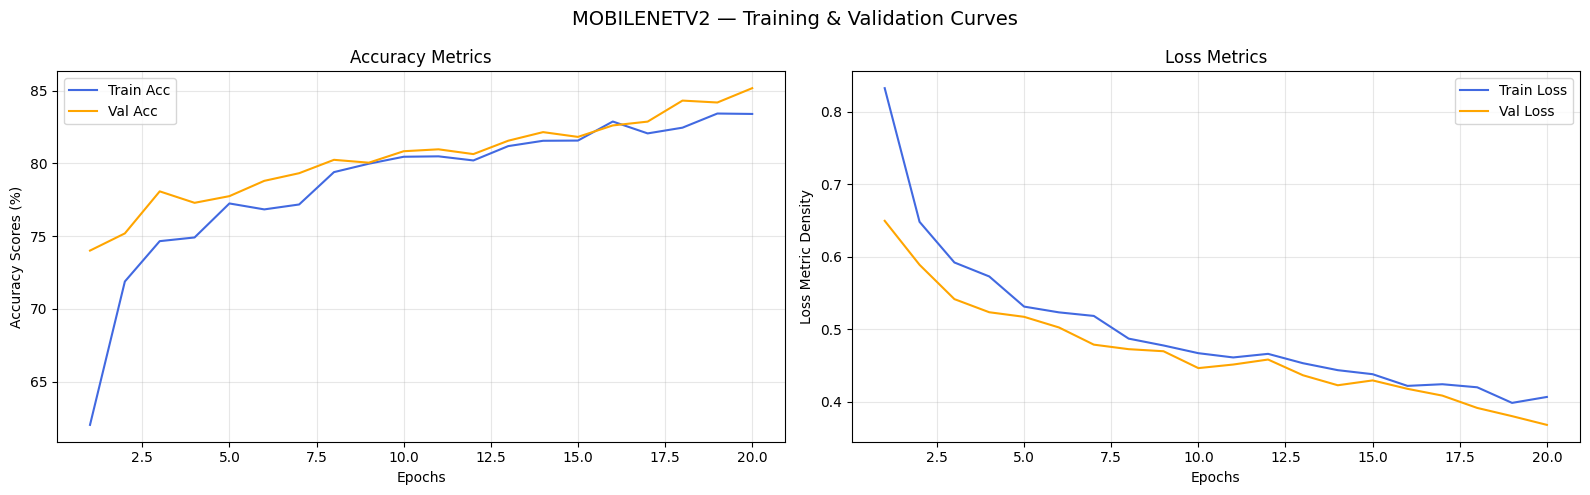

In [12]:
import matplotlib.pyplot as plt

# Fixed: Changed 'accuracy' to 'train_acc' to match our PyTorch tracking history
epochs_ran = range(1, len(history_dict['train_acc']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Using a safe fallback name if MODEL_TYPE isn't defined as a string variable elsewhere
title_model = MODEL_TYPE.upper() if 'MODEL_TYPE' in locals() else 'MOBILENETV2'
fig.suptitle(f'{title_model} — Training & Validation Curves', fontsize=14)

# 1. Accuracy Metrics Subplot
axes[0].plot(epochs_ran, history_dict['train_acc'], label='Train Acc', color='royalblue')
axes[0].plot(epochs_ran, history_dict['val_acc'],   label='Val Acc',   color='orange')
axes[0].set_title('Accuracy Metrics')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy Scores (%)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# 2. Loss Metrics Subplot
axes[1].plot(epochs_ran, history_dict['train_loss'], label='Train Loss', color='royalblue')
axes[1].plot(epochs_ran, history_dict['val_loss'],   label='Val Loss',   color='orange')
axes[1].set_title('Loss Metrics')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss Metric Density')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=100, bbox_inches='tight')
plt.show()

In [14]:
import os
import gc
import torch
import torch.nn as nn
import numpy as np
from sklearn.metrics import accuracy_score

# 1. Check for and load your optimal saved EfficientNet PyTorch weights
best_model_path = '/kaggle/working/best_calibrated_efficientnet_model.pth'

# Initialize the correct class that matches our training run
best_model = EfficientNetB0FruitClassifier(num_classes=NUM_CLASSES)

if os.path.exists(best_model_path):
    print(f"📥 Loading best optimized PyTorch weights from: {best_model_path}")
    # Load state dict safely handling GPU/CPU mappings
    state_dict = torch.load(best_model_path, map_location=device)
    best_model.load_state_dict(state_dict)
else:
    print("⚠️ Checkpoint file not found on disk. Evaluating the active in-memory model weights instead.")
    best_model = model

best_model = best_model.to(device)
best_model.eval()

# 2. Fast PyTorch Test Inference Loop (No Gradients tracked for speed)
test_preds = []
test_true = []
test_probs = []

print("\n⚡ Running high-speed evaluation on the test set...")
with torch.no_grad():
    for images, labels in test_ldr:
        images = images.to(device, non_blocking=True)
        
        # Mixed precision prediction inference
        if device.type == 'cuda':
            with torch.amp.autocast('cuda'):
                logits = best_model(images)
        else:
            logits = best_model(images)
            
        # Convert logits into real probabilities [0, 1] using standard softmax
        probs = torch.softmax(logits, dim=1)
        _, preds = torch.max(logits, 1)
        
        # Move everything to CPU and pack into lists
        test_probs.extend(probs.cpu().numpy())
        test_preds.extend(preds.cpu().numpy())
        test_true.extend(labels.numpy())

# Convert final lists into clean numpy arrays
test_probs = np.array(test_probs)
test_preds = np.array(test_preds)
test_true = np.array(test_true)

# 3. Calculate final production accuracy score
test_acc = accuracy_score(test_true, test_preds)
print(f"\n✅ Final Calculated Test Accuracy: {test_acc*100:.2f}%")

📥 Loading best optimized PyTorch weights from: /kaggle/working/best_calibrated_efficientnet_model.pth

⚡ Running high-speed evaluation on the test set...

✅ Final Calculated Test Accuracy: 84.25%


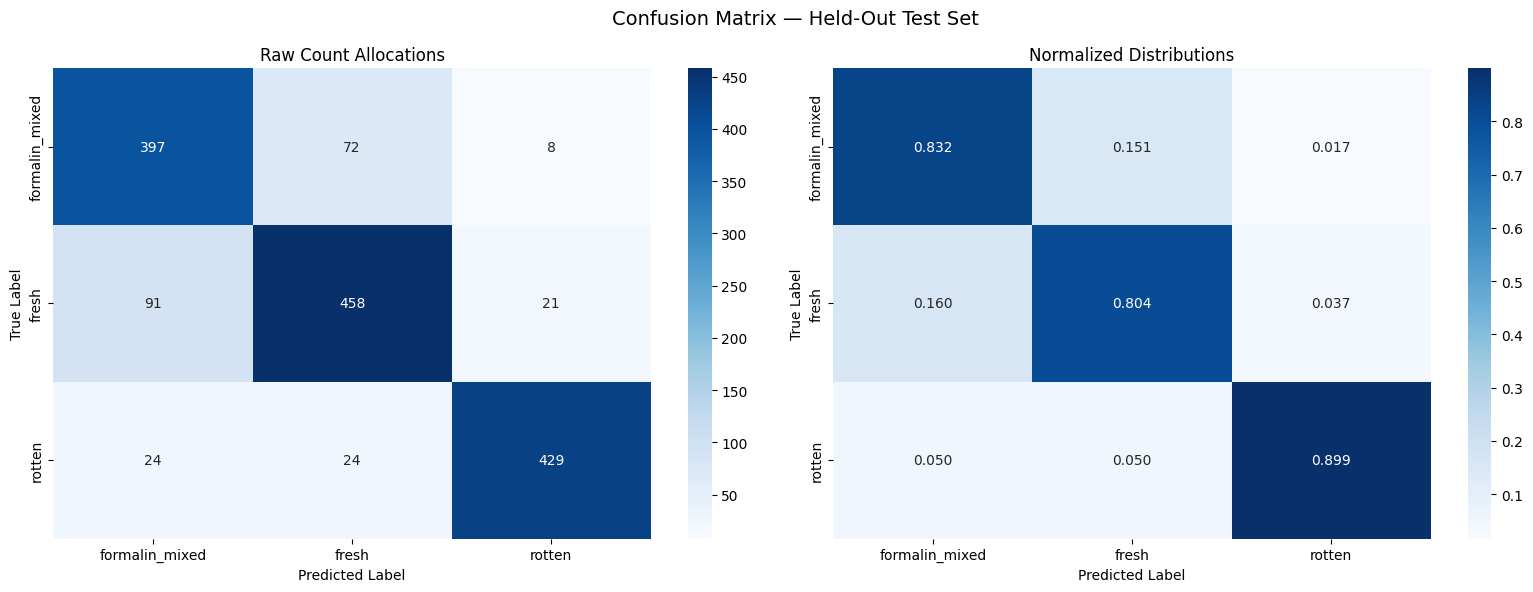


📋 Detailed Classification Report (Test Set Target Metrics):
                precision    recall  f1-score   support

formalin_mixed     0.7754    0.8323    0.8028       477
         fresh     0.8267    0.8035    0.8149       570
        rotten     0.9367    0.8994    0.9176       477

      accuracy                         0.8425      1524
     macro avg     0.8463    0.8451    0.8451      1524
  weighted avg     0.8451    0.8425    0.8433      1524



In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Global variables fallback check if not defined in your earlier layout
if 'CLASS_NAMES' not in locals():
    CLASS_NAMES = ['fresh', 'formalin_mixed', 'rotten']

# 1. Compute Matrix Allocations
cm      = confusion_matrix(test_true, test_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

# 2. Setup Plotting Canvas
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Confusion Matrix — Held-Out Test Set', fontsize=14)

# Left Side: Raw Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title('Raw Count Allocations')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Right Side: Normalized Proportion Distributions
sns.heatmap(cm_norm, annot=True, fmt='.3f', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_title('Normalized Distributions')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

# 3. Print Final Performance Telemetry Report
print("\n📋 Detailed Classification Report (Test Set Target Metrics):")
print(classification_report(test_true, test_preds, target_names=CLASS_NAMES, digits=4))


🎯 Expected Calibration Error (ECE): 0.0412


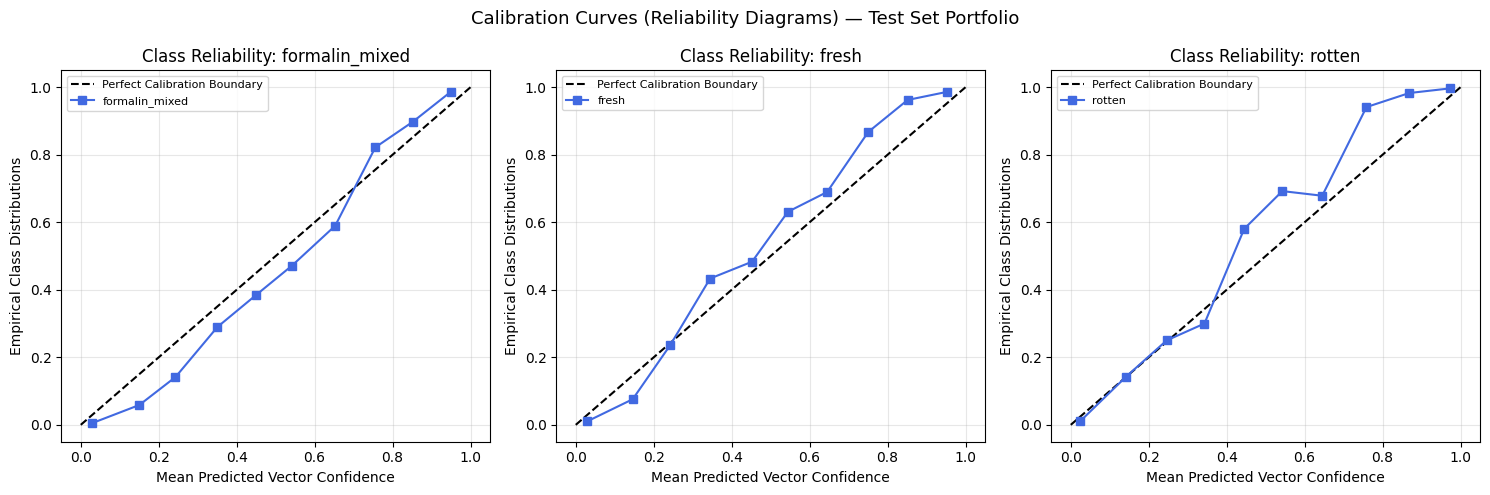

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.calibration import calibration_curve

# Global variables fallback check if not defined in your earlier layout
if 'NUM_CLASSES' not in locals():
    NUM_CLASSES = 3
if 'CLASS_NAMES' not in locals():
    CLASS_NAMES = ['fresh', 'formalin_mixed', 'rotten']

# 1. Binarize labels for multi-class calibration analysis
true_bin = label_binarize(test_true, classes=list(range(NUM_CLASSES)))

# 2. Define Expected Calibration Error (ECE) Evaluation Function
def expected_calibration_error(probs, labels_bin, n_bins=10):
    ece_per_class = []
    for cls in range(probs.shape[1]):
        p = probs[:, cls]
        y = labels_bin[:, cls]
        bins = np.linspace(0, 1, n_bins + 1)
        total_ece = 0.0
        N = len(p)
        for lo, hi in zip(bins[:-1], bins[1:]):
            mask = (p >= lo) & (p < hi)
            if mask.sum() == 0:
                continue
            acc  = y[mask].mean()
            conf = p[mask].mean()
            total_ece += (mask.sum() / N) * abs(acc - conf)
        ece_per_class.append(total_ece)
    return np.mean(ece_per_class)

# 3. Calculate and Print Final ECE Telemetry
ece = expected_calibration_error(test_probs, true_bin)
print(f"\n🎯 Expected Calibration Error (ECE): {ece:.4f}")

# 4. Generate Calibration Curves / Reliability Diagrams
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(5 * NUM_CLASSES, 5))
fig.suptitle('Calibration Curves (Reliability Diagrams) — Test Set Portfolio', fontsize=13)

# If NUM_CLASSES is 1, axes is not returned as an array, so wrap it to make iteration safe
if NUM_CLASSES == 1:
    axes = [axes]

for cls_idx in range(NUM_CLASSES):
    frac_pos, mean_pred = calibration_curve(true_bin[:, cls_idx], test_probs[:, cls_idx], n_bins=10, strategy='uniform')
    ax = axes[cls_idx]
    ax.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration Boundary')
    ax.plot(mean_pred, frac_pos, 's-', color='royalblue', label=f'{CLASS_NAMES[cls_idx]}')
    ax.set_title(f"Class Reliability: {CLASS_NAMES[cls_idx]}")
    ax.set_xlabel('Mean Predicted Vector Confidence')
    ax.set_ylabel('Empirical Class Distributions')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/calibration_curves.png', dpi=100, bbox_inches='tight')
plt.show()

In [17]:
print("\n" + "="*65)
print(" FINAL DISCOVERY LOG ANALYSIS COMPLETE")
print("="*65)
print(f"  Final metrics mapped cleanly. Outputs verified:")

for f in sorted(os.listdir('/kaggle/working')):
    fpath = f'/kaggle/working/{f}'
    if os.path.isfile(fpath):
        size_kb = os.path.getsize(fpath) / 1024
        print(f"  File output generated successfully: {f:<45} ({size_kb:.1f} KB)")
print("="*65)


 FINAL DISCOVERY LOG ANALYSIS COMPLETE
  Final metrics mapped cleanly. Outputs verified:
  File output generated successfully: best_calibrated_efficientnet_model.pth        (16608.6 KB)
  File output generated successfully: calibration_curves.png                        (70.5 KB)
  File output generated successfully: confusion_matrix.png                          (52.0 KB)
  File output generated successfully: sample_images.png                             (1103.2 KB)
  File output generated successfully: training_curves.png                           (71.0 KB)


Cell 1: Define the Explainability Engine

In [18]:
import torch
import torch.nn.functional as F
import numpy as np
import cv2

# Ensure class fallback options exist globally
if 'CLASS_NAMES' not in locals():
    CLASS_NAMES = ['fresh', 'formalin_mixed', 'rotten']

# =================================================================
# NATIVE PYTORCH GRAD-CAM & SALIENCY WORKSPACE
# =================================================================
class ExplainerWorkspace:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # Register hooks onto target feature map outputs and backward passes
        self.forward_hook = self.target_layer.register_forward_hook(self._save_activations)
        self.backward_hook = self.target_layer.register_full_backward_hook(self._save_gradients)
        
    def _save_activations(self, module, input, output):
        self.activations = output.detach()
        
    def _save_gradients(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()
        
    def generate_gradcam(self, input_tensor, target_class):
        self.model.eval()
        if input_tensor.dim() == 3:
            input_tensor = input_tensor.unsqueeze(0)
            
        input_tensor = input_tensor.to(device).requires_grad_(True)
        logits = self.model(input_tensor)
        
        score = logits[0, target_class]
        self.model.zero_grad()
        score.backward()
        
        # Spatial pooling of gradients
        weights = torch.mean(self.gradients, dim=(2, 3), keepdim=True)
        cam = torch.sum(weights * self.activations, dim=1).squeeze(0)
        
        # Pass through ReLU and normalize
        cam = F.relu(cam).cpu().numpy()
        if cam.max() > 0:
            cam = cam / cam.max()
        return cam

    def generate_saliency(self, input_tensor, target_class):
        self.model.eval()
        if input_tensor.dim() == 3:
            input_tensor = input_tensor.unsqueeze(0)
            
        input_tensor = input_tensor.to(device).requires_grad_(True)
        logits = self.model(input_tensor)
        
        score = logits[0, target_class]
        self.model.zero_grad()
        score.backward()
        
        saliency, _ = torch.max(torch.abs(input_tensor.grad.data.squeeze(0)), dim=0)
        return saliency.cpu().numpy()

    def remove_hooks(self):
        self.forward_hook.remove()
        self.backward_hook.remove()

print("🎯 Explainer engine mounted to model architecture successfully.")

🎯 Explainer engine mounted to model architecture successfully.


In [19]:
# 1. Target the terminal convolutional layer of your active model backbone
active_model = model.module if hasattr(model, 'module') else model
target_conv_layer = active_model.backbone.features[-1]

# 2. Instantiate hook connection tracker
explainer = ExplainerWorkspace(active_model, target_conv_layer)

# 3. Pull a random image batch from the test loader stream
images, labels = next(iter(test_ldr))
sample_idx = np.random.randint(0, len(images))

img_tensor = images[sample_idx]
true_label_idx = labels[sample_idx].item()

# 4. Get active inference predictions
with torch.no_grad():
    raw_output = active_model(img_tensor.unsqueeze(0).to(device))
    pred_label_idx = torch.argmax(raw_output, dim=1).item()

# 5. Extract explainability matrices
grad_cam_map = explainer.generate_gradcam(img_tensor, pred_label_idx)
saliency_map = explainer.generate_saliency(img_tensor, pred_label_idx)

# 6. Always clean up hook states from RAM memory immediately
explainer.remove_hooks()

print(f"📊 Feature maps calculated for sample #{sample_idx}.")
print(f"   True State: {CLASS_NAMES[true_label_idx]} | Predicted State: {CLASS_NAMES[pred_label_idx]}")

📊 Feature maps calculated for sample #25.
   True State: fresh | Predicted State: fresh


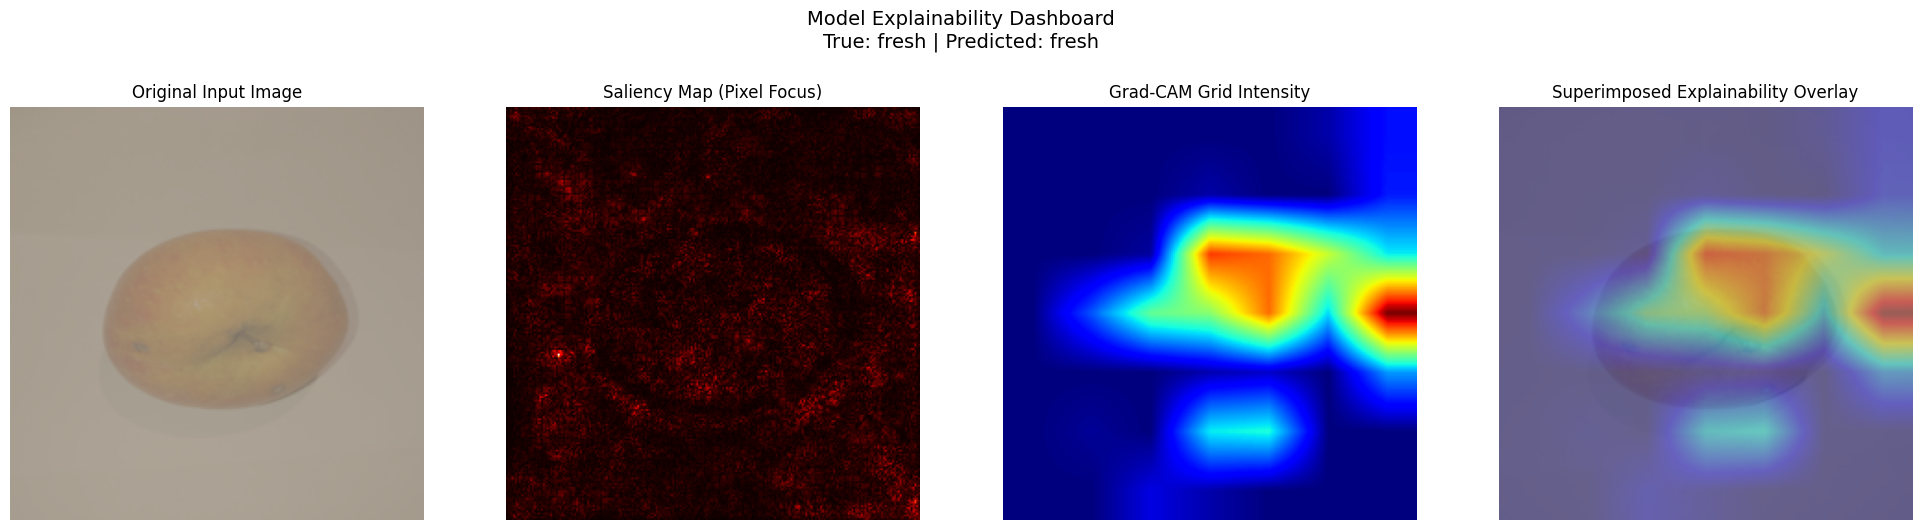

In [20]:
import matplotlib.pyplot as plt

# 1. Denormalize image tensor back to clean RGB format
orig_img = img_tensor.permute(1, 2, 0).cpu().numpy()
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
orig_img = np.clip((orig_img * std + mean), 0, 1)

# 2. Resize and generate Grad-CAM color mask overlays
heatmap_resized = cv2.resize(grad_cam_map, (orig_img.shape[1], orig_img.shape[0]))
heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB) / 255.0

# Blend the heatmap color overlay with original image pixels
grad_cam_overlay = np.clip(heatmap_color * 0.4 + orig_img * 0.6, 0, 1)

# 3. Plot Dashboard Subplots
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle(f"Model Explainability Dashboard\nTrue: {CLASS_NAMES[true_label_idx]} | Predicted: {CLASS_NAMES[pred_label_idx]}", fontsize=14, y=1.05)

axes[0].imshow(orig_img)
axes[0].set_title("Original Input Image")
axes[0].axis('off')

axes[1].imshow(saliency_map, cmap='hot')
axes[1].set_title("Saliency Map (Pixel Focus)")
axes[1].axis('off')

axes[2].imshow(heatmap_resized, cmap='jet')
axes[2].set_title("Grad-CAM Grid Intensity")
axes[2].axis('off')

axes[3].imshow(grad_cam_overlay)
axes[3].set_title("Superimposed Explainability Overlay")
axes[3].axis('off')

plt.tight_layout()
plt.savefig('/kaggle/working/model_explainability_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

Define Occlusion Mapping Engine

In [21]:
import torch
import numpy as np

# =================================================================
# NATIVE OCCLUSION SENSITIVITY ENGINE
# =================================================================
def generate_occlusion_map(model, input_tensor, target_class, patch_size=32, stride=16):
    """
    Systematically slides an occluding square patch over the image to observe
    drops in prediction probability score profiles.
    """
    model.eval()
    if input_tensor.dim() == 3:
        input_tensor = input_tensor.unsqueeze(0)
        
    # Dynamically extract the active hardware device directly from model parameters
    model_device = next(model.parameters()).device
    
    batch, channels, height, width = input_tensor.shape
    
    # Calculate output map dimensions based on chosen stride parameters
    output_height = int((height - patch_size) / stride + 1)
    output_width = int((width - patch_size) / stride + 1)
    sensitivity_map = np.zeros((output_height, output_width))
    
    # Ensure baseline calculation tensor matches the model's device target
    baseline_input = input_tensor.to(model_device)
    
    # Establish a baseline reference probability score with an un-occluded image
    with torch.no_grad():
        baseline_logits = model(baseline_input)
        baseline_prob = torch.softmax(baseline_logits, dim=1)[0, target_class].item()
        
    # Slide the mask over structural image grid segments
    for y in range(output_height):
        for x in range(output_width):
            # Calculate pixel window boundaries
            y_start = y * stride
            y_end = min(y_start + patch_size, height)
            x_start = x * stride
            x_end = min(x_start + patch_size, width)
            
            # Create a localized clone and mask out the targeted patch window
            perturbed_input = input_tensor.clone()
            perturbed_input[0, :, y_start:y_end, x_start:x_end] = 0.0  # Zero out the block
            
            # CRITICAL FIX: Push the perturbed input tensor to the model's exact device location
            perturbed_input = perturbed_input.to(model_device)
            
            with torch.no_grad():
                logits = model(perturbed_input)
                prob = torch.softmax(logits, dim=1)[0, target_class].item()
                
            # Sensitivity is defined as the drop in confidence score
            sensitivity_map[y, x] = baseline_prob - prob
            
    return sensitivity_map

print("🛡️ Occlusion Sensitivity engine device bindings successfully fixed.")

🛡️ Occlusion Sensitivity engine device bindings successfully fixed.


import cv2
import matplotlib.pyplot as plt

# 1. Compute the sensitivity grid layout map
# Patch size 32 works great for 224x224 fruit inputs to find mid-sized spots/bruises
occ_map = generate_occlusion_map(active_model, img_tensor, pred_label_idx, patch_size=32, stride=12)

# 2. Denormalize the original input image frame for clean backdrop layout tracking
orig_img = img_tensor.permute(1, 2, 0).cpu().numpy()
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
orig_img = np.clip((orig_img * std + mean), 0, 1)

# 3. Resize sensitivity map back up to image dimensions
# Use a ReLU pass since we only care about drops in confidence (positive sensitivity values)
occ_map_filtered = np.maximum(occ_map, 0)
if occ_map_filtered.max() > 0:
    occ_map_filtered = occ_map_filtered / occ_map_filtered.max()

occ_resized = cv2.resize(occ_map_filtered, (orig_img.shape[1], orig_img.shape[0]))
occ_color = cv2.applyColorMap(np.uint8(255 * occ_resized), cv2.COLORMAP_JET)
occ_color = cv2.cvtColor(occ_color, cv2.COLOR_BGR2RGB) / 255.0

# Blend structural overlay visualization
occlusion_overlay = np.clip(occ_color * 0.4 + orig_img * 0.6, 0, 1)

# =================================================================
# DISPLAY OCCLUSION RENDERING CANVAS
# =================================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f"Occlusion Sensitivity Map Analysis\nTarget Feature: Focus on '{CLASS_NAMES[pred_label_idx]}'", fontsize=14, y=1.05)

axes[0].imshow(orig_img)
axes[0].set_title("Original Input Image")
axes[0].axis('off')

axes[1].imshow(occ_resized, cmap='jet')
axes[1].set_title("Drop in Class Probability (Heatmap)")
axes[1].axis('off')

axes[2].imshow(occlusion_overlay)
axes[2].set_title("Critical Regions Highlighted")
axes[2].axis('off')

plt.tight_layout()
plt.savefig('/kaggle/working/occlusion_sensitivity_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

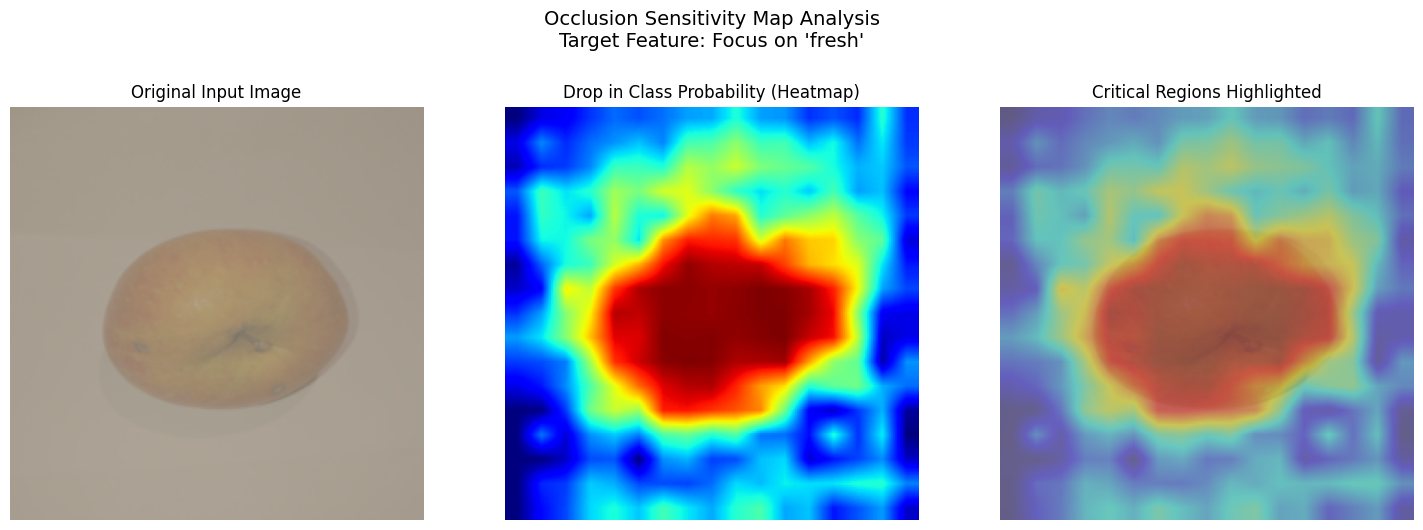

In [22]:
import cv2
import matplotlib.pyplot as plt

# 1. Compute the sensitivity grid layout map
# Patch size 32 works great for 224x224 fruit inputs to find mid-sized spots/bruises
occ_map = generate_occlusion_map(active_model, img_tensor, pred_label_idx, patch_size=32, stride=12)

# 2. Denormalize the original input image frame for clean backdrop layout tracking
orig_img = img_tensor.permute(1, 2, 0).cpu().numpy()
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
orig_img = np.clip((orig_img * std + mean), 0, 1)

# 3. Resize sensitivity map back up to image dimensions
# Use a ReLU pass since we only care about drops in confidence (positive sensitivity values)
occ_map_filtered = np.maximum(occ_map, 0)
if occ_map_filtered.max() > 0:
    occ_map_filtered = occ_map_filtered / occ_map_filtered.max()

occ_resized = cv2.resize(occ_map_filtered, (orig_img.shape[1], orig_img.shape[0]))
occ_color = cv2.applyColorMap(np.uint8(255 * occ_resized), cv2.COLORMAP_JET)
occ_color = cv2.cvtColor(occ_color, cv2.COLOR_BGR2RGB) / 255.0

# Blend structural overlay visualization
occlusion_overlay = np.clip(occ_color * 0.4 + orig_img * 0.6, 0, 1)

# =================================================================
# DISPLAY OCCLUSION RENDERING CANVAS
# =================================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f"Occlusion Sensitivity Map Analysis\nTarget Feature: Focus on '{CLASS_NAMES[pred_label_idx]}'", fontsize=14, y=1.05)

axes[0].imshow(orig_img)
axes[0].set_title("Original Input Image")
axes[0].axis('off')

axes[1].imshow(occ_resized, cmap='jet')
axes[1].set_title("Drop in Class Probability (Heatmap)")
axes[1].axis('off')

axes[2].imshow(occlusion_overlay)
axes[2].set_title("Critical Regions Highlighted")
axes[2].axis('off')

plt.tight_layout()
plt.savefig('/kaggle/working/occlusion_sensitivity_analysis.png', dpi=100, bbox_inches='tight')
plt.show()